# Chapter 6 From Concept to Application: Code Your First Neural Networks with Python and PyTorch

# 🏠 Predicting House Prices with Deep Learning - Complete Tutorial

In this comprehensive tutorial, we'll build a **deep learning model** to predict house prices using PyTorch. This project demonstrates the complete machine learning workflow:

- **Data Generation**: Creating synthetic housing data
- **Data Preprocessing**: Encoding categorical variables and normalization
- **Model Building**: Designing a feedforward neural network
- **Training**: Optimizing the model with backpropagation
- **Evaluation**: Assessing performance with metrics and visualizations
- **Deployment**: Saving and loading models for inference

Let's get started! 🚀

## 📊 Step 1: Generate Synthetic House Price Data

We'll create a synthetic dataset with **1000 houses** containing the following features:

- **square_feet**: Size of the house (1000-4000 sq ft)
- **crime_rate**: Neighborhood crime rate (1-10 scale)
- **school_quality**: Quality of nearby schools (1-10 scale)
- **bedrooms**: Number of bedrooms (1-5)
- **market_demand**: Market condition (low, medium, high)
- **renovated**: Whether the house was recently renovated (0 or 1)

The **price** is calculated using a domain-inspired formula that combines these features with realistic weights and adjustments.

In [56]:
# =============================================================
#  Chapter 6 – Generating a Synthetic House-Price Dataset
# =============================================================
#  This script creates a 1 000-row CSV of fictitious houses.
#  Each house has six input features and one target (price).
#  We will use this dataset throughout the book to train our
#  first neural network with PyTorch.
# =============================================================

import numpy as np
import pandas as pd

# ---------- reproducibility ----------
np.random.seed(42)

# ---------- configuration ----------
NUM_HOUSES = 1000

# ---------- generate input features ----------
square_feet    = np.random.randint(1000, 4000, NUM_HOUSES)
crime_rate     = np.random.uniform(1, 10, NUM_HOUSES)
school_quality = np.random.randint(1, 11, NUM_HOUSES)
bedrooms       = np.random.randint(1, 6, NUM_HOUSES)
market_demand  = np.random.choice(["low", "medium", "high"], NUM_HOUSES)
renovated      = np.random.choice([0, 1], NUM_HOUSES)

# ---------- compute base price ----------
price = (
    50_000
    + square_feet    * 100
    + school_quality * 5_000
    - crime_rate     * 3_000
    + bedrooms       * 7_000
).astype(float)

# ---------- apply market-demand multiplier ----------
demand_multiplier = {"low": 0.85, "medium": 1.0, "high": 1.2}

for i in range(NUM_HOUSES):
    price[i] *= demand_multiplier[market_demand[i]]

# ---------- add renovation bonus ----------
price += renovated * 15_000

# ---------- round price----------
#Keep price as a whole integer — no decimals
price = np.round(price).astype(int)
#crime_rate to 2 decimals for cleanliness
crime_rate = np.round(crime_rate,2)

# ---------- assemble DataFrame ----------
data = pd.DataFrame({
    "square_feet":    square_feet,
    "crime_rate":     np.round(crime_rate, 4),
    "school_quality": school_quality,
    "bedrooms":       bedrooms,
    "market_demand":  market_demand,
    "renovated":      renovated,
    "price":          price,
})

# ---------- save & preview ----------
data.to_csv("house_prices_data.csv", index=False)

print("Dataset generated successfully!")
print(f"   Shape: {data.shape}\n")
print("First 20 rows:")
data.head(20)

Dataset generated successfully!
   Shape: (1000, 7)

First 20 rows:


,square_feet,crime_rate,school_quality,bedrooms,market_demand,renovated,price
0,1860,9.36,9,3,low,1,247821
1,2294,6.01,6,4,low,0,271462
2,2130,6.14,1,5,medium,0,284566
3,2095,3.52,4,1,low,0,234549
4,2638,7.93,1,4,high,0,387628
5,3169,2.68,6,1,low,1,351472
6,1466,3.91,4,2,high,0,262633
7,2238,4.83,3,4,low,1,271966
8,1330,5.57,3,1,high,1,240953
9,2482,3.18,9,3,high,1,440586


## 🔍 Step 2: Load and Explore the Data

Now that we've generated our dataset, let's load it from the CSV file and explore its characteristics. We'll examine:

- Dataset dimensions and column types
- Statistical summary of numerical features
- Check for missing values

This exploration helps us understand the data distribution and identify any preprocessing needs.

In [57]:
# =============================================================
#  Step 2 – Load and Explore the Data
# =============================================================
#  Before feeding data into a model we should always understand
#  what we're working with: shape, types, missing values, and
#  basic statistics.  This is called Exploratory Data Analysis
#  (EDA) — a habit every ML practitioner should build early.
# =============================================================

import pandas as pd

# ---------- load ----------
data = pd.read_csv("house_prices_data.csv")

# ---------- quick shape check ----------
print("Dataset Overview")
print("=" * 55)
print(f"   Rows    : {data.shape[0]}")
print(f"   Columns : {data.shape[1]}")
print(f"   Features: {list(data.columns)}\n")

# ---------- data types & memory ----------
print("Data Types")
print("=" * 55)
print(data.dtypes.to_string())
print()

# ---------- statistical summary (numeric columns) ----------
print("Statistical Summary (Numeric Columns)")
print("=" * 55)
print(data.describe().round(2).to_string())
print()

# ---------- missing values ----------
missing = data.isnull().sum()
print("Missing Values")
print("=" * 55)

if missing.sum() == 0:
    print("No missing values — dataset is clean!\n")
else:
    print(missing[missing > 0].to_string())
    print()

# ---------- categorical column: market_demand ----------
print("Market Demand Distribution")
print("=" * 55)
counts = data["market_demand"].value_counts()

for level, count in counts.items():
    pct = count / len(data) * 100
    print(f"   {level:<8s} → {count:>4d}  ({pct:.1f}%)")

print()

# ---------- price range sanity check ----------
print("Price Range (USD)")
print("=" * 55)
print(f"   Min : {data['price'].min():>10,}")
print(f"   Max : {data['price'].max():>10,}")
print(f"   Mean: {data['price'].mean():>10,.0f}")
print()

# ---------- peek at the first few rows ----------
print("First 5 Rows:")
print("=" * 55)
data.head()

Dataset Overview
   Rows    : 1000
   Columns : 7
   Features: ['square_feet', 'crime_rate', 'school_quality', 'bedrooms', 'market_demand', 'renovated', 'price']

Data Types
square_feet         int64
crime_rate        float64
school_quality      int64
bedrooms            int64
market_demand      object
renovated           int64
price               int64

Statistical Summary (Numeric Columns)
       square_feet  crime_rate  school_quality  bedrooms  renovated      price
count      1000.00     1000.00         1000.00   1000.00    1000.00    1000.00
mean       2518.77        5.54            5.43      2.95       0.51  346940.48
std         865.76        2.61            2.81      1.43       0.50  100102.41
min        1001.00        1.04            1.00      1.00       0.00  139133.00
25%        1774.50        3.17            3.00      2.00       0.00  266022.50
50%        2509.50        5.65            5.00      3.00       1.00  344697.00
75%        3237.50        7.78            8.00      

,square_feet,crime_rate,school_quality,bedrooms,market_demand,renovated,price
0,1860,9.36,9,3,low,1,247821
1,2294,6.01,6,4,low,0,271462
2,2130,6.14,1,5,medium,0,284566
3,2095,3.52,4,1,low,0,234549
4,2638,7.93,1,4,high,0,387628


## 🔄 Step 3: Categorical Encoding and Data Preprocessing

Neural networks require numerical input, so we need to convert our categorical feature **market_demand** into a numeric format.

We'll use **One-Hot Encoding**, which creates binary columns for each category:
- `market_demand_low` (1 if low, 0 otherwise)
- `market_demand_medium` (1 if medium, 0 otherwise)
- `market_demand_high` (1 if high, 0 otherwise)

After encoding, we'll separate our features (X) from the target variable (y).

In [58]:
# =============================================================
#  Step 3 – Categorical Encoding & Data Preprocessing
# =============================================================
#  Neural networks only understand numbers, so we must convert
#  any text-based (categorical) columns into numeric form.
#
#  We use ONE-HOT ENCODING for the "market_demand" column:
#     "low"    → [1, 0, 0]
#     "medium" → [0, 1, 0]
#     "high"   → [0, 0, 1]
#
#  After encoding we split the data into:
#     X  →  input features   (what the model sees)
#     y  →  target variable   (what the model predicts)
# =============================================================

# ---------- one-hot encode the categorical column ----------
data_encoded = pd.get_dummies(
    data,
    columns=["market_demand"],
    prefix="market",
    dtype=int,                       # keep values as 0/1 integers
)

print("One-Hot Encoding Complete")
print("=" * 55)
print(f"   Before : {data.shape[1]} columns  →  After : {data_encoded.shape[1]} columns")
print(f"   Rows   : {data_encoded.shape[0]} (unchanged)\n")

# show old vs new columns so students see exactly what changed
original_cols = set(data.columns)
new_cols      = set(data_encoded.columns) - original_cols

print("   Removed column  :", "market_demand")
print("   Added columns   :", sorted(new_cols))
print()

# Save feature names before .values conversion
feature_names = data_encoded.drop(TARGET, axis=1).columns.tolist()

# ---------- separate features (X) and target (y) ----------
TARGET = "price"

X = data_encoded.drop(TARGET, axis=1).values   # 2-D numpy array
y = data_encoded[TARGET].values                 # 1-D numpy array

print("Feature / Target Split")
print("=" * 55)
print(f"   X shape : {X.shape}  (samples × features)")
print(f"   y shape : {y.shape}  (samples,)\n")

# ---------- quick sanity check ----------
print("Encoded Data — First 5 Rows")
print("=" * 55)
data_encoded.head()

One-Hot Encoding Complete
   Before : 7 columns  →  After : 9 columns
   Rows   : 1000 (unchanged)

   Removed column  : market_demand
   Added columns   : ['market_high', 'market_low', 'market_medium']

Feature / Target Split
   X shape : (1000, 8)  (samples × features)
   y shape : (1000,)  (samples,)

Encoded Data — First 5 Rows


,square_feet,crime_rate,school_quality,bedrooms,renovated,price,market_high,market_low,market_medium
0,1860,9.36,9,3,1,247821,0,1,0
1,2294,6.01,6,4,0,271462,0,1,0
2,2130,6.14,1,5,0,284566,0,0,1
3,2095,3.52,4,1,0,234549,0,1,0
4,2638,7.93,1,4,0,387628,1,0,0


## ✂️ Step 4: Train-Test Split & Feature Normalization

We split our dataset into training and testing sets using an **80-20 split**:
- **80% (800 samples)** → the textbook the model learns from
- **20% (200 samples)** → the final exam the model has never seen

---

### 🔢 What Is StandardScaler?

`StandardScaler` converts every value by asking one question: **"How far are you from the average?"**

scaled_value = (original_value - mean) / standard_deviation

After scaling, each column has a **mean ≈ 0** and **std ≈ 1**, putting all features on the same playing field. Without this, a feature like `square_feet` (range 1000–4000) would dominate `crime_rate` (range 1–10) simply because its numbers are bigger — not because it's more important.

**Why does this matter for neural networks?**
- Prevents large-scale features from dominating small-scale ones
- Keeps loss values manageable, so training stays stable
- Allows a normal learning rate (like 0.001) to work out of the box
- Improves gradient descent convergence — the model learns faster

---

### ⚠️ Data Leakage — The #1 Beginner Mistake

**Rule: Split FIRST, then scale. Never the other way around.**

Think of it like a teacher preparing an exam. The teacher writes questions based on what she taught in class (training data). Students see the exam (test data) only on exam day. If the answer sheet leaks before the exam, every student scores 95% — but they didn't actually learn anything. Their scores are fake-good.

If you fit the scaler on ALL data before splitting, the mean and standard deviation contain information from the test set. That information quietly leaks into training. Your test metrics look great but they're lying — the model won't perform that well on truly new data.

---

### 🔧 fit() vs transform() — Three Methods Explained

| Method             | What It Does                              | Analogy                          |
|--------------------|-------------------------------------------|----------------------------------|
| `fit()`            | Calculates and **memorizes** mean & std   | Reading the data, taking notes   |
| `transform()`      | **Applies** the memorized formula to data | Using those notes to convert     |
| `fit_transform()`  | Does both in **one shot**                 | Read + convert in a single step  |

**Training data** → `fit_transform()` (learn the rules and apply them)
**Test data** → `transform()` only (follow the same rules, never learn new ones)

We never call `fit()` on test data because:
1. **Two different rulers** — training and test get scaled differently, so the model sees inconsistent values
2. **The model learned one language** — it learned patterns based on training's scale; changing the scale at test time is like handing it a book in a different language
3. **Real world breaks** — in production you get one new house at a time; fitting a scaler on one sample gives std = 0 and your app crashes

---

### 📏 Why Two Separate Scalers (scaler_X and scaler_y)?

`StandardScaler` is smart — when you pass it a table with multiple columns, it calculates a **separate mean and std for each column** automatically. So one `scaler_X` handles `square_feet` (range 1000–4000) and `crime_rate` (range 1–10) correctly without mixing them up.

But price (y) was **separated from X** earlier, so `scaler_X` never saw it and has no mean or std stored for it. Price also lives in a completely different range (130,000–600,000). We need a separate `scaler_y`.

**Why not combine everything into one scaler?** You could — the math would be correct. But after prediction, you need to convert scaled predictions back to real dollars using `inverse_transform`. With one combined scaler, you'd have to build a fake 9-column row every time just to decode one price value. With separate scalers, it's just one clean line:

real_price = scaler_y.inverse_transform(predicted)

| Scaler      | Trained On          | Knows About                     |
|-------------|---------------------|---------------------------------|
| `scaler_X`  | All feature columns | Numbers in range 1–4,000        |
| `scaler_y`  | Price column only   | Numbers in range 130,000–600,000|

---

### 🔄 The Correct Workflow (in order)

1. Split        →  X_train, X_test, y_train, y_test
2. Fit scaler_X →  learn mean & std from X_train only
3. Transform X  →  scale X_train and X_test with scaler_X
4. Fit scaler_y →  learn mean & std from y_train only
5. Transform y  →  scale y_train and y_test with scaler_y
6. Convert      →  turn everything into PyTorch tensors

Finally, we convert all NumPy arrays to **PyTorch FloatTensors** — the format PyTorch needs for model training.

> 💡 **Remember:** After the model predicts a price, call `scaler_y.inverse_transform(prediction)` to convert the scaled output back to real USD.

In [59]:
# =============================================================
#  Step 4 – Train-Test Split & Feature Normalization
# =============================================================
#  ORDER MATTERS!  We must:
#
#    1. Split first   → keep test data completely unseen
#    2. Fit scalers on TRAINING data only
#    3. Transform both sets with those same scalers
#
#  We scale BOTH X (features) and y (price) because:
#    - Features have different ranges (sq ft in 1000s, crime 1-10)
#    - Price is in the 100,000s — huge loss values make
#      training unstable if left unscaled
#
#  ⚠️  DATA LEAKAGE — a common beginner mistake:
#       If you fit the scaler on ALL data (before splitting),
#       statistics from the test set leak into training.
#       The model quietly "cheats" and your test metrics
#       become over-optimistic.  Always split THEN scale.
# =============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# ---------- 1. train / test split (80 / 20) ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print("Train / Test Split")
print("=" * 55)
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Testing samples  : {X_test.shape[0]}")
print(f"   Feature count    : {X_train.shape[1]}\n")

# ---------- 2. normalize features (X) ----------
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)    # fit + transform
X_test  = scaler_X.transform(X_test)         # transform only

print("Feature Normalization (X)")
print("=" * 55)
print(f"   Training mean : {X_train.mean():.6f}  (≈ 0 if correct)")
print(f"   Training std  : {X_train.std():.6f}   (≈ 1 if correct)")
print(f"   Test mean     : {X_test.mean():.6f}    (slightly off 0 — normal)")
print(f"   Test std      : {X_test.std():.6f}\n")

# ---------- 3. normalize target (y) ----------
# Separate scaler for price — different mean & std than features.
# reshape(-1, 1) because StandardScaler expects a 2D array.

scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))   # fit + transform
y_test  = scaler_y.transform(y_test.reshape(-1, 1))        # transform only

print("Target Normalization (y = price)")
print("=" * 55)
print(f"   Training mean : {y_train.mean():.6f}  (≈ 0 if correct)")
print(f"   Training std  : {y_train.std():.6f}   (≈ 1 if correct)")
print(f"   Test mean     : {y_test.mean():.6f}")
print(f"   Test std      : {y_test.std():.6f}\n")

# ---------- 4. convert to PyTorch tensors ----------
X_train = torch.FloatTensor(X_train)
X_test  = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)    # already shaped (-1, 1)
y_test  = torch.FloatTensor(y_test)     # already shaped (-1, 1)

print("PyTorch Tensors Ready")
print("=" * 55)
print(f"   X_train : {X_train.shape}   dtype: {X_train.dtype}")
print(f"   y_train : {y_train.shape}     dtype: {y_train.dtype}")
print(f"   X_test  : {X_test.shape}    dtype: {X_test.dtype}")
print(f"   y_test  : {y_test.shape}      dtype: {y_test.dtype}\n")

# ---------- quick verification ----------
print("🔍 Leakage Check")
print("=" * 55)
print("   Both X and y scalers were fit on training data only.")
print("   Test means slightly off 0 confirms no leakage.")
print()
print("💡 Remember: after prediction, convert back to real USD:")
print('   real_price = scaler_y.inverse_transform(predicted)')

Train / Test Split
   Training samples : 800
   Testing samples  : 200
   Feature count    : 8

Feature Normalization (X)
   Training mean : 0.000000  (≈ 0 if correct)
   Training std  : 1.000000   (≈ 1 if correct)
   Test mean     : -0.025113    (slightly off 0 — normal)
   Test std      : 1.002373

Target Normalization (y = price)
   Training mean : -0.000000  (≈ 0 if correct)
   Training std  : 1.000000   (≈ 1 if correct)
   Test mean     : -0.066805
   Test std      : 1.021911

PyTorch Tensors Ready
   X_train : torch.Size([800, 8])   dtype: torch.float32
   y_train : torch.Size([800, 1])     dtype: torch.float32
   X_test  : torch.Size([200, 8])    dtype: torch.float32
   y_test  : torch.Size([200, 1])      dtype: torch.float32

🔍 Leakage Check
   Both X and y scalers were fit on training data only.
   Test means slightly off 0 confirms no leakage.

💡 Remember: after prediction, convert back to real USD:
   real_price = scaler_y.inverse_transform(predicted)


## 🧠 Step 5: Define the Neural Network Architecture

A neural network is a stack of **layers**, where each layer is a group of **neurons**. Every neuron takes in numbers, multiplies them by **weights** (which it learns during training), adds a **bias**, and passes the result to the next layer. That's it — the entire magic of deep learning is just this process repeated many times.

### Our Architecture

Input Layer (8 features)

 ↓

Hidden Layer 1  →  64 neurons  →  ReLU

 ↓


Hidden Layer 2  →  32 neurons  →  ReLU

 ↓


Hidden Layer 3  →  16 neurons  →  ReLU

 ↓


Output Layer    →   1 neuron   →  No activation (linear)

**Why does the network get narrower (64 → 32 → 16 → 1)?** Think of it like a funnel. The first layer captures many raw patterns from the 8 input features. Each subsequent layer compresses and refines those patterns into higher-level understanding, until the final layer distills everything into a single number — the predicted price.

---

### 🔑 What Is a "Fully Connected" (Dense) Layer?

Each neuron in one layer is connected to **every** neuron in the next layer. In PyTorch this is called `nn.Linear`. The word "linear" means the layer performs a simple math operation:

output = (input × weights) + bias

If we stacked linear layers alone, the entire network would just be one big linear equation — it could only learn straight-line relationships. That's where activation functions come in.

---

### ⚡ ReLU — The Activation Function

**ReLU (Rectified Linear Unit)** is the simplest and most popular activation function:

ReLU(x) = max(0, x)

In plain English: if the number is positive, keep it; if it's negative, make it zero.

**Why do we need it?** Without an activation function, stacking 100 linear layers is mathematically identical to having just one layer. ReLU breaks this linearity and lets the network learn **curves, bends, and complex patterns** — like the non-linear relationship between crime rate, school quality, and house price.

**Why ReLU specifically?**
- **Simple** — just a comparison with zero, so it's extremely fast to compute
- **Effective** — avoids the "vanishing gradient" problem that plagued older activations like Sigmoid in deep networks; gradients flow cleanly through ReLU during backpropagation
- **Proven** — used in the vast majority of modern neural networks as the default choice

---

### 🚫 Why No Activation on the Output Layer?

This is a **regression** task — we're predicting a continuous price that could be any number. If we put ReLU on the output, the model could never predict a negative value (which matters when y is scaled and centered around 0). If we used Sigmoid, the output would be squashed between 0 and 1. The output layer stays **linear** so the network is free to output whatever value it needs.

> 💡 **Quick rule:** Regression → no output activation. Classification → use Sigmoid (binary) or Softmax (multi-class).

---

### 📐 What Are "Parameters"?

Every connection between neurons has a **weight**, and every neuron has a **bias**. These are the numbers the model adjusts during training to reduce prediction error. Together they're called **parameters**.

For our model:
- Layer 1: (8 inputs × 64 neurons) + 64 biases = **576**
- Layer 2: (64 × 32) + 32 = **2,080**
- Layer 3: (32 × 16) + 16 = **528**
- Output:  (16 × 1) + 1 = **17**
- **Total: 3,201 trainable parameters**

That's 3,201 knobs the model will tune during training to learn the relationship between house features and price.

---

### 🧱 nn.Sequential — Clean Way to Stack Layers

Instead of defining each layer separately and wiring them manually, PyTorch's `nn.Sequential` lets us define the entire architecture as one readable stack. The data flows through each layer in order, top to bottom — no extra plumbing needed.

In [60]:
# =============================================================
#  Step 5 – Define the Neural Network Architecture
# =============================================================
#  Our network is a simple "fully connected" (dense) model:
#
#    Input (8 features)
#      ↓
#    Hidden Layer 1  →  64 neurons  →  ReLU
#      ↓
#    Hidden Layer 2  →  32 neurons  →  ReLU
#      ↓
#    Hidden Layer 3  →  16 neurons  →  ReLU
#      ↓
#    Output Layer    →   1 neuron   →  (no activation)
#
#  WHY no activation on the output?
#  We're predicting a continuous price — it can be any number.
#  ReLU or Sigmoid would clip or squash the output, which is
#  wrong for regression.  The final layer stays "linear" so the
#  network can output any value it needs.
# =============================================================

import torch.nn as nn

class HousePriceModel(nn.Module):

    def __init__(self, input_size):
        super().__init__()           # modern Python — no need for class name

        # ---------- layer stack ----------
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),   # input  → 64 neurons
            nn.ReLU(),
            nn.Linear(64, 32),           # 64     → 32 neurons
            nn.ReLU(),
            nn.Linear(32, 16),           # 32     → 16 neurons
            nn.ReLU(),
            nn.Linear(16, 1),            # 16     → 1  (predicted price)
        )

    def forward(self, x):
        return self.network(x)


# ---------- create the model ----------
input_size = X_train.shape[1]              # number of features (8)
model = HousePriceModel(input_size)

# ---------- print a summary ----------
print("✅ Neural Network Defined")
print("=" * 55)
print(f"   Input features : {input_size}")
print(f"   Architecture   : {input_size} → 64 → 32 → 16 → 1")
print(f"   Activations    : ReLU (hidden layers), Linear (output)")
print()

# count trainable parameters so students see the model's "size"
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"   Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable:,}")
print()
print("📐 Model Structure:")
print(model)

✅ Neural Network Defined
   Input features : 8
   Architecture   : 8 → 64 → 32 → 16 → 1
   Activations    : ReLU (hidden layers), Linear (output)

   Total parameters     : 3,201
   Trainable parameters : 3,201

📐 Model Structure:
HousePriceModel(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


## ⚙️ Step 6: Initialize Model, Loss Function, and Optimizer

Now we'll set up the key components for training:

**1. Model Initialization**: Create an instance of our `HousePriceModel` with 8 input features

**2. Loss Function**: **Mean Squared Error (MSE)**
   - MSE = (1/n) × Σ(predicted - actual)²
   - Penalizes larger errors more heavily
   - Standard loss for regression problems

**3. Optimizer**: **Adam (Adaptive Moment Estimation)**
   - Learning rate: 0.001
   - Combines benefits of momentum and RMSprop
   - Adapts learning rate for each parameter
   - Generally converges faster than standard SGD

In [61]:
# =============================================================
#  Step 6 – Initialize Model, Loss Function & Optimizer
# =============================================================
#  Three ingredients are needed before training can begin:
#
#    1. MODEL      →  the neural network we defined in Step 5
#    2. LOSS FN    →  measures how wrong the predictions are
#    3. OPTIMIZER  →  adjusts the weights to reduce that loss
#
#  Think of it like archery practice:
#    - You shoot an arrow (model makes a prediction)
#    - You measure how far from the bullseye (loss function)
#    - You adjust your aim for the next shot (optimizer)
# =============================================================

import torch.optim as optim

# ---------- 1. model (already defined in Step 5) ----------
input_size = X_train.shape[1]
model = HousePriceModel(input_size)

# ---------- 2. loss function ----------
# MSE = Mean Squared Error
# It calculates:  average of (predicted - actual)²
# Large errors get punished MORE because they're squared.
#   e.g.  off by 2  → penalty = 4
#         off by 10 → penalty = 100  (not 5x worse, but 25x!)

criterion = nn.MSELoss()

# ---------- 3. optimizer ----------
# Adam = Adaptive Moment Estimation
# It's the most popular optimizer for beginners because:
#   - It adjusts the learning rate per-parameter automatically
#   - It works well out of the box with minimal tuning
#
# lr (learning rate) = how big each adjustment step is
#   too large → overshoots, training explodes
#   too small → learns very slowly
#   0.001    → a safe default starting point

LEARNING_RATE = 0.001

optimizer = optim.Adam(
    model.parameters(),     # tell Adam WHICH weights to adjust
    lr=LEARNING_RATE,
)

# ---------- summary ----------
print("✅ Training Components Ready")
print("=" * 55)
print(f"   Model        : HousePriceModel")
print(f"   Input size   : {input_size} features")
print(f"   Loss function: MSELoss (Mean Squared Error)")
print(f"   Optimizer    : Adam")
print(f"   Learning rate: {LEARNING_RATE}")
print()

# parameter breakdown per layer
print("📋 Model Architecture")
print("=" * 55)
print(model)
print()

print("📊 Parameter Count Per Layer")
print("=" * 55)
for name, param in model.named_parameters():
    print(f"   {name:<25s}  shape: {str(list(param.shape)):<15s}  params: {param.numel():>5,}")

total_params = sum(p.numel() for p in model.parameters())
print(f"\n   {'TOTAL':<25s}  {'':<15s}  params: {total_params:>5,}")

✅ Training Components Ready
   Model        : HousePriceModel
   Input size   : 8 features
   Loss function: MSELoss (Mean Squared Error)
   Optimizer    : Adam
   Learning rate: 0.001

📋 Model Architecture
HousePriceModel(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

📊 Parameter Count Per Layer
   network.0.weight           shape: [64, 8]          params:   512
   network.0.bias             shape: [64]             params:    64
   network.2.weight           shape: [32, 64]         params: 2,048
   network.2.bias             shape: [32]             params:    32
   network.4.weight           shape: [16, 32]         params:   512
   network.4.bias             shape: [16]             params:    16
   network.6.weight   

## 🏋️ Step 7: Train the Model

We'll train the model for **200 epochs**. Each epoch consists of:

**1. Forward Pass**:
   - Input data flows through the network
   - Model generates predictions

**2. Loss Calculation**:
   - Compare predictions with actual prices
   - Calculate MSE loss

**3. Backward Pass (Backpropagation)**:
   - Compute gradients of loss with respect to weights
   - Propagate gradients backward through the network

**4. Weight Update**:
   - Optimizer adjusts weights to minimize loss
   - Uses Adam optimization algorithm

We'll track the loss at every epoch to monitor training progress.

In [62]:
# =============================================================
#  Step 7 – Train the Model
# =============================================================
#  Training is a loop that repeats the same 4 steps:
#
#    1. FORWARD PASS   →  feed data through the network,
#                         get predictions
#    2. COMPUTE LOSS   →  measure how wrong the predictions are
#    3. BACKWARD PASS  →  calculate gradients (which direction
#                         should each weight move?)
#    4. UPDATE WEIGHTS →  nudge weights in that direction
#
#  One full cycle through the training data = 1 EPOCH.
#  We repeat for many epochs until the loss stops improving.
# =============================================================

# ---------- training configuration ----------
EPOCHS      = 200
PRINT_EVERY = 20          # print progress every N epochs

# ---------- tracking ----------
train_losses = []          # store loss per epoch for plotting later

print("🚀 Training Started")
print("=" * 55)
print(f"   Epochs          : {EPOCHS}")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Features        : {X_train.shape[1]}")
print()

# ---------- training loop ----------
for epoch in range(EPOCHS):
    model.train()                                # set to training mode

    # Step 1 — Forward pass
    predictions = model(X_train)          # network outputs predictions

    # Step 2 — Compute loss
    loss = criterion(predictions, y_train)

    # Step 3 — Backward pass
    optimizer.zero_grad()                        # clear OLD gradients first
    loss.backward()                              # compute NEW gradients

    # Step 4 — Update weights
    optimizer.step()                             # nudge weights to reduce loss

    # Record loss for this epoch
    current_loss = loss.item()
    train_losses.append(current_loss)

    # Print progress
    if (epoch + 1) % PRINT_EVERY == 0:
        improvement = ""
        if len(train_losses) > PRINT_EVERY:
            prev = train_losses[-(PRINT_EVERY + 1)]
            change = ((current_loss - prev) / prev) * 100
            improvement = f"  ({change:+.2f}%)"
        print(f"   Epoch {epoch+1:>4d}/{EPOCHS}   Loss: {current_loss:.6f}{improvement}")

# ---------- training summary ----------
print()
print("✅ Training Complete!")
print("=" * 55)
print(f"   Starting loss : {train_losses[0]:.6f}")
print(f"   Final loss    : {train_losses[-1]:.6f}")
print(f"   Reduction     : {((train_losses[-1] - train_losses[0]) / train_losses[0]) * 100:.2f}%")

🚀 Training Started
   Epochs          : 200
   Training samples: 800
   Features        : 8

   Epoch   20/200   Loss: 0.871106
   Epoch   40/200   Loss: 0.541828  (-37.80%)
   Epoch   60/200   Loss: 0.081400  (-84.98%)
   Epoch   80/200   Loss: 0.014578  (-82.09%)
   Epoch  100/200   Loss: 0.004591  (-68.50%)
   Epoch  120/200   Loss: 0.002581  (-43.78%)
   Epoch  140/200   Loss: 0.001900  (-26.40%)
   Epoch  160/200   Loss: 0.001530  (-19.49%)
   Epoch  180/200   Loss: 0.001279  (-16.37%)
   Epoch  200/200   Loss: 0.001094  (-14.50%)

✅ Training Complete!
   Starting loss : 1.023393
   Final loss    : 0.001094
   Reduction     : -99.89%


# 📊 Steps 8 & 9: Evaluate Model Performance

---

## 🎯 What Are We Doing?

Now that our model has **finished training** (like a student completing their study sessions), it's time for the **final exam!**

We test the model on the **test set** — data it has **never seen before** — to measure how well it **truly learned** the patterns, rather than just memorizing answers.

---

## 🧮 Key Metric: R² Score (Coefficient of Determination)

The **R² Score** answers one simple question:

> *"How much of the variation in house prices can our model explain?"*

### Formula

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

| Term | Full Name | What It Measures |
|------|-----------|-----------------|
| **SS_res** | Sum of Squared **Residuals** | How far our **predictions** are from **actual** prices |
| **SS_tot** | **Total** Sum of Squares | How far **actual** prices are from the **average** price |

### 💡 Simple Analogy

Imagine house prices range from **100K to 500K** (lots of variation).

- **SS_tot** captures that total spread
- **SS_res** captures how much spread is **left over** after our model makes predictions
- **R²** tells us what **percentage** of the spread our model **eliminated**

---

## 📈 How to Interpret R² Score

| R² Score | Rating | What It Means |
|----------|--------|---------------|
| **0.95 – 1.00** | 🏆 Excellent | Near-perfect predictions — model nails the prices |
| **0.80 – 0.95** | ✅ Good | Strong predictions — captures most patterns |
| **0.60 – 0.80** | 🔄 Moderate | Decent — but missing some important patterns |
| **0.30 – 0.60** | ⚠️ Weak | Struggles — needs significant improvement |
| **0.00 – 0.30** | ❌ Poor | Barely better than just guessing the average price |
| **Below 0.00** | 🚫 Terrible | **Worse** than guessing the average — something is broken |

> 🎯 **Target**: A good regression model typically achieves **R² > 0.70**

---

## 📏 Second Metric: MSE (Mean Squared Error)

| Metric | Formula | Goal |
|--------|---------|------|
| **MSE** | Average of (Actual − Predicted)² | **Lower is better** |

### Quick Example

| House | Actual Price | Predicted Price | Error | Squared Error |
|-------|-------------|----------------|-------|---------------|
| 🏠 A | 200,000 | 210,000 | 10,000 | 100,000,000 |
| 🏠 B | 350,000 | 340,000 | 10,000 | 100,000,000 |
| 🏠 C | 500,000 | 480,000 | 20,000 | 400,000,000 |
| | | | **MSE →** | **200,000,000** |

---

## 🔄 Evaluation vs Training Mode

| Aspect | Training Mode | Evaluation Mode |
|--------|--------------|-----------------|
| **Purpose** | Learn patterns | Test performance |
| **Data used** | Training set | Test set (unseen) |
| **Dropout** | Active (prevents overfitting) | Turned OFF |
| **Gradient tracking** | ON (needed for learning) | OFF (saves memory) |
| **PyTorch command** | `model.train()` | `model.eval()` |

---

## ⬇️ Let's Run the Evaluation!

In [63]:
# ============================================================
# STEP 7: FIX FEATURE / INPUT MISMATCH
# ============================================================
# 🧠 WHAT IS A FEATURE MISMATCH?
#
# Imagine a lock that needs exactly 8 keys to open.
# If you give it 7 keys → it won't open (too few!)
# If you give it 9 keys → it won't open (too many!)
# You need EXACTLY 8 keys, in the RIGHT order.
#
# Our model is that lock.
# It was BUILT to accept exactly 8 features (inputs).
# So our training data AND testing data must BOTH
# have exactly 8 features — no more, no less.
#
# This step checks everything is aligned before we
# test our model. Think of it as a safety inspection
# before the final exam!
# ============================================================

# --- Print shapes so we can visually inspect ---
# .shape gives us (rows, columns)
# Example: (1000, 8) means 1000 houses with 8 features each
print("📊 Data Shape Check")
print("=" * 50)
print(f"X_train shape: {X_train.shape}")   # training features
print(f"X_test shape:  {X_test.shape}")     # testing features
print(f"y_train shape: {y_train.shape}")    # training prices
print(f"y_test shape:  {y_test.shape}")     # testing prices

# --- Check 1: Do train and test have the same number of features? ---
# X_train.shape[1] = number of columns (features) in training data
# X_test.shape[1]  = number of columns (features) in testing data
# These MUST be equal!
assert X_train.shape[1] == X_test.shape[1], \
    f"❌ STOP! Train has {X_train.shape[1]} features but Test has {X_test.shape[1]}!"

print(f"\n✅ Check 1 PASSED: Both have {X_train.shape[1]} features")

# --- Check 2: Does the model expect the same number of features? ---
# model.network[0] = the FIRST layer of our model
#   → This is where data enters the model
#   → .in_features tells us how many inputs it expects
#
# YOUR MODEL ARCHITECTURE (for reference):
#   model.network[0] → Linear(8 → 64)  ← INPUT layer
#   model.network[1] → ReLU
#   model.network[2] → Linear(64 → 32) ← Hidden layer 1
#   model.network[3] → ReLU
#   model.network[4] → Linear(32 → 16) ← Hidden layer 2
#   model.network[5] → ReLU
#   model.network[6] → Linear(16 → 1)  ← OUTPUT layer

model_expects = model.network[0].in_features   # should be 8
data_provides  = X_train.shape[1]               # should be 8

print(f"\n🔍 Model's first layer expects: {model_expects} inputs")
print(f"📊 Our data provides:           {data_provides} inputs")

assert model_expects == data_provides, \
    f"❌ STOP! Model expects {model_expects} but data gives {data_provides}!"

print(f"\n✅ Check 2 PASSED: Model and data are aligned!")

# --- Check 3: Does the output layer match our target? ---
# model.network[6] = the LAST layer (output layer)
# .out_features = how many outputs the model produces
# For house price prediction, we want exactly 1 output (the price)
output_size = model.network[6].out_features

print(f"\n🏠 Model output size: {output_size}")
print(f"🎯 y_test shape:     {y_test.shape}")

assert output_size == 1, \
    f"❌ STOP! Model outputs {output_size} values but we need 1 (price)!"

print(f"\n✅ Check 3 PASSED: Model outputs 1 value (price)")

# --- Final Summary ---
print("\n" + "=" * 50)
print("🎉 ALL CHECKS PASSED!")
print("=" * 50)
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Testing samples  : {X_test.shape[0]}")
print(f"   Features per sample: {X_train.shape[1]}")
print(f"   Model input size : {model_expects}")
print(f"   Model output size: {output_size}")
print("   Everything is aligned — ready to evaluate! ✅")


# ============================================================
# STEP 8: EVALUATE MODEL PERFORMANCE
# ============================================================
# 🧠 WHAT IS MODEL EVALUATION?
#
# During training, the model studied the training data
# (like a student doing homework).
# Now we test it on data it has NEVER seen before
# (like giving the student a final exam).
#
# If the model does well on NEW data, it truly learned
# the patterns — not just memorized the answers!
#
# We measure performance using two metrics:
#   1. MSE (Mean Squared Error) → how far off are predictions?
#   2. R² Score → what % of price variation can the model explain?
# ============================================================

# We need r2_score from sklearn to measure accuracy
from sklearn.metrics import r2_score

# --- Step 8a: Switch model to EVALUATION MODE ---
# During training, the model uses special tricks like dropout
# (randomly turning off some neurons) to learn better.
# In evaluation mode, we turn OFF those tricks so we get
# the model's REAL, honest predictions.
# Think of it like: "Okay, no more practice. Show me what you got!"
model.eval()

# --- Step 8b: Make predictions on TEST data ---
# torch.no_grad() = tells PyTorch "don't track calculations"
#
# WHY? During training, PyTorch records every math operation
# so it can learn from mistakes (called backpropagation).
# During testing, we DON'T need to learn — just predict.
# Turning this off saves memory and speeds things up.
with torch.no_grad():

    # Feed the test features (X_test) into the model
    # The model will output predicted house prices
    y_pred = model(X_test)

# --- Step 8c: Calculate MSE (Mean Squared Error) ---
# MSE = average of (actual price - predicted price)²
#
# EXAMPLE:
#   Actual price  = $200,000
#   Predicted     = $210,000
#   Error         = $10,000
#   Squared error = $10,000² = 100,000,000
#
# We average ALL squared errors across every test house.
# LOWER MSE = BETTER (closer predictions)
test_loss = criterion(y_pred, y_test)

# --- Step 8d: Convert tensors to NumPy arrays ---
# WHY? sklearn's r2_score only works with NumPy arrays,
# not PyTorch tensors. So we need to convert.
#
# .detach() = safely disconnect from PyTorch's tracking system
#             (prevents errors if gradients are still attached)
# .numpy()  = convert from PyTorch tensor → NumPy array
y_test_np = y_test.detach().numpy()   # actual house prices
y_pred_np = y_pred.detach().numpy()   # model's predicted prices

# --- Step 8e: Calculate R² Score ---
# R² (R-Squared) is the most intuitive accuracy metric:
#
#   R² = 1.00 → PERFECT! Model predicts prices exactly
#   R² = 0.85 → GREAT!   Model explains 85% of price differences
#   R² = 0.50 → OKAY.    Model explains only half
#   R² = 0.00 → BAD.     Model is no better than guessing average
#   R² < 0    → AWFUL.   Model is WORSE than just guessing average
#
# SIMPLE ANALOGY:
#   If house prices vary a lot (cheap houses, expensive houses),
#   R² tells us how much of that variation our model captures.
r2 = r2_score(y_test_np, y_pred_np)

# --- Step 8f: Print Results ---
print("\n📈 Model Evaluation Results")
print("=" * 50)

# MSE: lower is better
print(f"Test Loss (MSE): {test_loss.item():.2f}")

# R²: higher is better (max = 1.0)
print(f"R² Score:        {r2:.4f}")

# --- Step 8g: Human-friendly performance label ---
# This makes it easy for beginners to understand the result
if r2 >= 0.9:
    performance = "Excellent ✨"    # 90%+ → amazing model
elif r2 >= 0.7:
    performance = "Good 👍"         # 70-89% → solid, reliable
elif r2 >= 0.5:
    performance = "Moderate 🔄"     # 50-69% → needs improvement
else:
    performance = "Poor ⚠️"         # below 50% → something is wrong

print(f"Performance:     {performance}")
print(f"\n💡 The model explains {r2*100:.2f}% of the variance in house prices.")

# --- Step 8h: Detailed Interpretation ---
print("\n📖 What This Means:")
print("-" * 50)

if r2 >= 0.9:
    print("Your model is highly accurate!")
    print("It can predict house prices very close to actual values.")
    print("The 8 features you used are strong predictors of price.")
elif r2 >= 0.7:
    print("Your model is performing well!")
    print("It captures most of the price patterns in the data.")
    print("You could try adding more features to push it higher.")
elif r2 >= 0.5:
    print("Your model learned some patterns but is missing others.")
    print("Try: more epochs, more features, or a bigger network.")
else:
    print("Your model is struggling to learn the patterns.")
    print("Try these fixes:")
    print("  1. Check your data for errors or missing values")
    print("  2. Make sure features are scaled/normalized")
    print("  3. Increase training epochs (train longer)")
    print("  4. Add more neurons or layers to the model")
    print("  5. Try a lower learning rate (e.g., 0.0001)")

# ============================================================
# 🎯 QUICK REFERENCE CARD
# ============================================================
# METRIC        MEANING              GOOD VALUE
# ---------     ------------------   ----------
# MSE           Average squared      As LOW as
#               prediction error     possible
#
# R² Score      % of variance        As HIGH as
#               explained            possible (max 1.0)
#
# COMMON FIXES FOR POOR RESULTS:
#   → Scale features (StandardScaler)
#   → Train longer (more epochs)
#   → Bigger model (more neurons)
#   → More/better features
#   → Lower learning rate
# ============================================================

📊 Data Shape Check
X_train shape: torch.Size([800, 8])
X_test shape:  torch.Size([200, 8])
y_train shape: torch.Size([800, 1])
y_test shape:  torch.Size([200, 1])

✅ Check 1 PASSED: Both have 8 features

🔍 Model's first layer expects: 8 inputs
📊 Our data provides:           8 inputs

✅ Check 2 PASSED: Model and data are aligned!

🏠 Model output size: 1
🎯 y_test shape:     torch.Size([200, 1])

✅ Check 3 PASSED: Model outputs 1 value (price)

🎉 ALL CHECKS PASSED!
   Training samples : 800
   Testing samples  : 200
   Features per sample: 8
   Model input size : 8
   Model output size: 1
   Everything is aligned — ready to evaluate! ✅

📈 Model Evaluation Results
Test Loss (MSE): 0.00
R² Score:        0.9982
Performance:     Excellent ✨

💡 The model explains 99.82% of the variance in house prices.

📖 What This Means:
--------------------------------------------------
Your model is highly accurate!
It can predict house prices very close to actual values.
The 8 features you used are strong 

# 🎯 Step 10: Visualize Predictions vs Actual Prices

This scatter plot compares our model's **predictions** against **actual house prices** — the ultimate visual test of how well the model learned.

---

## 📈 Reading the Chart

### 🔴 Red Dashed Line — *Perfect Prediction Line (y = x)*

> If the model were 100% accurate, every single dot would land exactly on this line.
> It represents the ideal scenario where **Predicted Price = Actual Price**.

### 🔵 Blue Dots — *Individual Predictions*

> Each dot is one house from the test set.

| Dot Position | Meaning |
|:---|:---|
| **On** the red line | ✅ Perfect prediction |
| **Close** to the red line | ✅ Accurate prediction |
| **Far** from the red line | ⚠️ Large prediction error |
| **Above** the red line | Model predicted **too high** |
| **Below** the red line | Model predicted **too low** |

---

## ✅ What Good Predictions Look Like

- **Tight clustering** — Points hug the diagonal line closely with minimal scatter
- **Even distribution** — No systematic drift above or below the line (no bias)
- **Consistent spread** — Similar variance across all price ranges (low → high)

---

## ⚠️ What to Watch For

| Pattern | Name | What It Means |
|:---|:---|:---|
| Points consistently **above or below** the line | **Systematic Bias** | Model is over/under-predicting on average |
| **Fan-shaped** spread (wider at higher prices) | **Heteroscedasticity** | Model struggles more with expensive homes |
| Isolated dots **far from** the cluster | **Outliers** | Potential data issues or model limitations |
| Dots form a **curve** instead of following the line | **Non-linearity** | Model is missing a non-linear relationship |

---

## 📊 Key Metrics Explained

| Metric | What It Measures | Simple Interpretation |
|:---|:---|:---|
| **MAE** *(Mean Absolute Error)* | Average size of errors in dollars | *"On average, the model is off by this much"* |
| **RMSE** *(Root Mean Squared Error)* | Average error, but penalizes big misses harder | *"Like MAE, but large errors hurt more"* |
| **Average Actual Price** | Baseline reference for context | *Compare MAE against this to gauge % accuracy* |

> 💡 **Quick Health Check:** Divide MAE by the Average Price.
> If the result is under **10%**, your model is doing well for a beginner project!
>
> *Example: MAE = 15,000 ÷ Avg Price = 200,000 → **7.5% error** → ✅ Solid!*

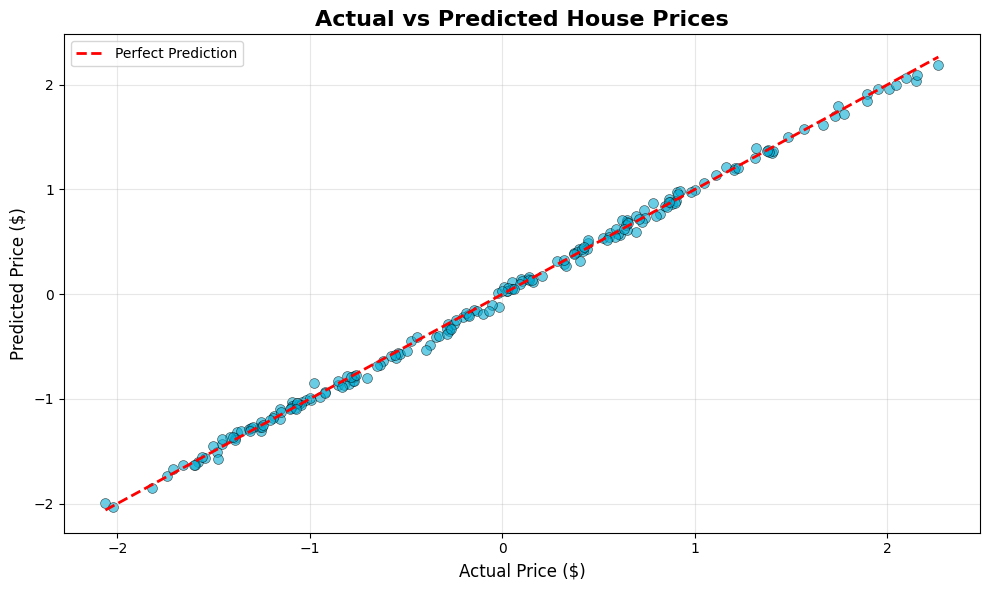


📊 Prediction Statistics:
Mean Absolute Error (MAE):    $0.03
Root Mean Squared Error (RMSE): $0.04
Average actual price:          $-0.07


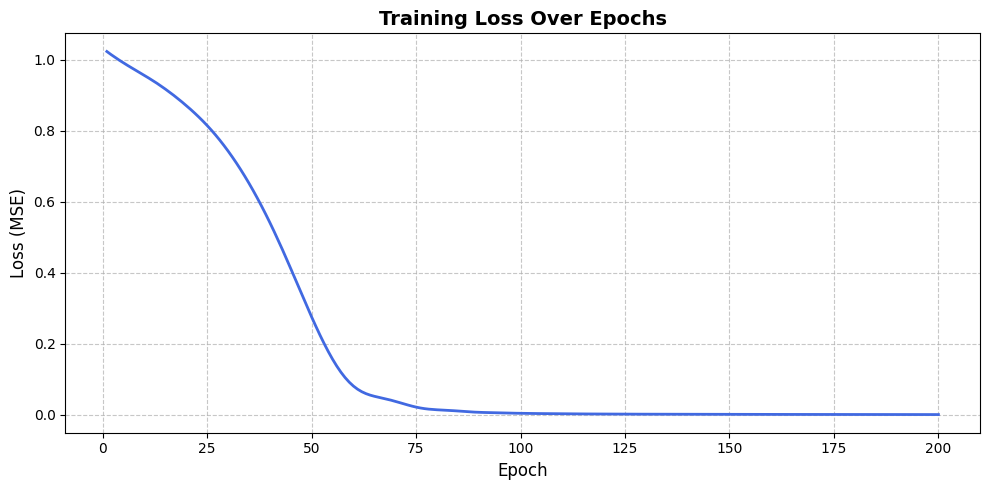

In [64]:
# ============================================
# Step 10: Visualize Predictions vs Actual Prices
# ============================================

# ---- Fix: Import missing libraries ----
import numpy as np              # For math operations (mean, sqrt, abs)
import matplotlib.pyplot as plt # For creating charts/graphs

# ---- Convert tensors to numpy arrays (if not already done) ----
# PyTorch tensors can't be plotted directly, so we convert them
# .detach() = removes from computation graph
# .cpu()    = moves data from GPU to CPU
# .numpy()  = converts to NumPy array
y_test_np = y_test.detach().cpu().numpy()
y_pred_np = y_pred.detach().cpu().numpy()

# ============================================
# PART 1: Create the Scatter Plot
# ============================================

# Create a blank canvas (10 inches wide, 6 inches tall)
plt.figure(figsize=(10, 6))

# Plot each house as a dot
#   x-axis = actual price (what the house really sold for)
#   y-axis = predicted price (what our model guessed)
plt.scatter(
    y_test_np,              # Actual prices (x-axis)
    y_pred_np,              # Predicted prices (y-axis)
    alpha=0.6,              # Slight transparency (so overlapping dots are visible)
    s=50,                   # Dot size
    color='#06AED5',        # Teal/cyan color
    edgecolors='black',     # Black border around each dot
    linewidth=0.5           # Thin border
)

# ---- Draw the "Perfect Prediction" line ----
# If our model was 100% accurate, every dot would sit on this line
# (because predicted price would exactly equal actual price)
min_val = min(y_test_np.min(), y_pred_np.min())  # Lowest price
max_val = max(y_test_np.max(), y_pred_np.max())  # Highest price
plt.plot(
    [min_val, max_val],     # x coordinates: from lowest to highest
    [min_val, max_val],     # y coordinates: same (makes a diagonal line)
    'r--',                  # Red dashed line
    linewidth=2,
    label='Perfect Prediction'
)

# ---- Add labels and styling ----
plt.title('Actual vs Predicted House Prices', fontsize=16, fontweight='bold')
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.legend(fontsize=10)         # Show the legend (explains the red line)
plt.grid(True, alpha=0.3)       # Light grid lines for readability
plt.tight_layout()              # Auto-adjust spacing so nothing gets cut off
plt.show()                      # Display the chart!

# ============================================
# PART 2: Calculate Prediction Statistics
# ============================================

# How far off was each prediction?
errors = y_test_np - y_pred_np  # Positive = model guessed too low
                                 # Negative = model guessed too high

# MAE = Mean Absolute Error
# "On average, how many dollars off was each prediction?"
# We use abs() because we don't care about direction, just size of error
mae = np.abs(errors).mean()

# RMSE = Root Mean Squared Error
# Similar to MAE but punishes BIG errors more heavily
# Step 1: Square each error  (makes all positive, amplifies big errors)
# Step 2: Take the mean       (average of squared errors)
# Step 3: Take square root     (brings back to dollar scale)
rmse = np.sqrt((errors ** 2).mean())

# ---- Print results ----
print("\n📊 Prediction Statistics:")
print("=" * 50)
print(f"Mean Absolute Error (MAE):    ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Average actual price:          ${y_test_np.mean():.2f}")


# ── Plot Training Loss ──
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, color='royalblue', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 💾 Step 11: Save the Trained Model

After investing time and computational resources in training our model, it's crucial to **save it for future use**.

**Why Save Models?**
- **Reusability**: Use the trained model without retraining
- **Deployment**: Deploy to production environments
- **Sharing**: Share models with team members or clients
- **Versioning**: Keep track of different model versions
- **Time-saving**: Avoid lengthy retraining processes

**What Gets Saved?**
- **Model weights (parameters)**: All learned weights and biases
- **Model architecture**: Layer structure and connections
- **Optimizer state** (optional): Useful for resuming training

**Best Practices:**
- Save after achieving satisfactory performance
- Use descriptive filenames with version numbers
- Include metadata (training date, performance metrics)
- Store models in a dedicated directory

We'll use PyTorch's `torch.save()` function to save our model's state dictionary to a `.pth` file.

In [65]:
# ============================================
# Step 11: Save Model + Scalers + Config
# ============================================
import os
import torch
import joblib

# ---- 1. Save model weights ----
model_path = "house_price_model.pth"
torch.save(model.state_dict(), model_path)

# ---- 2. Save both scalers ----
joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")

# ---- 3. Save full config bundle ----
config = {
    "model_state_dict": model.state_dict(),
    "input_size": input_size,
    "hidden_layers": [64, 32, 16],
    "output_size": 1,
    "epochs": EPOCHS,
    "learning_rate": optimizer.param_groups[0]['lr'],
    "feature_names": feature_names,
    "final_train_loss": train_losses[-1],
    "r2_score": r2,
    "test_mse": test_loss.item(),
}
bundle_path = "model_bundle.pth"
torch.save(config, bundle_path)

# ============================================
# Print Save Confirmation
# ============================================
print("✅ All artifacts saved successfully!")
print("=" * 55)
print(f"   📦 Model weights    : {model_path} ({os.path.getsize(model_path)/1024:.2f} KB)")
print(f"   📦 Feature scaler   : scaler_X.pkl ({os.path.getsize('scaler_X.pkl')/1024:.2f} KB)")
print(f"   📦 Target scaler    : scaler_y.pkl ({os.path.getsize('scaler_y.pkl')/1024:.2f} KB)")
print(f"   📦 Full bundle      : {bundle_path} ({os.path.getsize(bundle_path)/1024:.2f} KB)")

print("\n📝 Model Information:")
print(f"   - Architecture    : {input_size} → 64 → 32 → 16 → 1")
print(f"   - Training epochs : {EPOCHS}")
print(f"   - Final R² score  : {r2:.4f}")
print(f"   - Test MSE        : {test_loss.item():.2f}")
print(f"   - Features saved  : {len(feature_names)}")

print("\n🎉 Model is ready for deployment!")

# ============================================
# How to Load & Reproduce Predictions Later
# ============================================
# import torch, joblib
#
# # Step 1: Load the bundle
# bundle = torch.load("model_bundle.pth")
#
# # Step 2: Recreate architecture from saved config
# loaded_model = HousePriceModel(bundle["input_size"])
# loaded_model.load_state_dict(bundle["model_state_dict"])
# loaded_model.eval()
#
# # Step 3: Load both scalers
# scaler_X = joblib.load("scaler_X.pkl")
# scaler_y = joblib.load("scaler_y.pkl")
#
# # Step 4: Preprocess new data & predict
# new_data_scaled = scaler_X.transform(new_data_df)
# new_tensor = torch.FloatTensor(new_data_scaled)
# predicted_scaled = loaded_model(new_tensor)
#
# # Step 5: Convert back to real USD prices
# real_price = scaler_y.inverse_transform(predicted_scaled.detach().numpy())

✅ All artifacts saved successfully!
   📦 Model weights    : house_price_model.pth (16.27 KB)
   📦 Feature scaler   : scaler_X.pkl (0.79 KB)
   📦 Target scaler    : scaler_y.pkl (0.61 KB)
   📦 Full bundle      : model_bundle.pth (16.58 KB)

📝 Model Information:
   - Architecture    : 8 → 64 → 32 → 16 → 1
   - Training epochs : 200
   - Final R² score  : 0.9982
   - Test MSE        : 0.00
   - Features saved  : 8

🎉 Model is ready for deployment!


## 🔄 Step 12: Load Model and Make Predictions on New Data

Now let's demonstrate how to **load the saved model** and use it for inference on new, unseen data.

**Loading Process:**
1. **Recreate the model architecture**: Instantiate the same model class
2. **Load saved weights**: Use `model.load_state_dict()`
3. **Set to evaluation mode**: Call `model.eval()` to disable dropout/batch norm

**Making Predictions:**
- Prepare new data in the **same format** as training data
- Apply the **same preprocessing** (one-hot encoding, normalization)
- Convert to PyTorch tensors
- Pass through the model

**Real-World Deployment Considerations:**
- **Input validation**: Ensure features are within expected ranges
- **Error handling**: Handle missing or invalid data gracefully
- **Preprocessing pipeline**: Save and load the scaler with the model
- **API integration**: Wrap predictions in REST API for web applications
- **Monitoring**: Track prediction quality in production
- **Model updates**: Periodically retrain with new data

Let's load our model and predict prices for some example houses!

In [66]:
# ============================================
# Step 12: Load Model and Make Predictions
# ============================================
import numpy as np
import torch
import joblib

# ============================================
# PART 1: Load the Saved Model & Scalers
# ============================================
loaded_model = HousePriceModel(input_size)
loaded_model.load_state_dict(torch.load(model_path))
loaded_model.eval()

# Load both scalers
scaler_X = joblib.load("scaler_X.pkl")
scaler_y = joblib.load("scaler_y.pkl")

print("✅ Model & scalers loaded successfully!")
print("=" * 50)
print()

# ============================================
# PART 2: Define New Houses to Predict
# ============================================
new_houses = [
    {
        "square_feet": 2500,
        "crime_rate": 3.5,
        "school_quality": 8,
        "bedrooms": 4,
        "market_demand": "high",
        "renovated": 1,
        "description": "Luxury renovated family home in safe neighborhood"
    },
    {
        "square_feet": 1500,
        "crime_rate": 6.2,
        "school_quality": 5,
        "bedrooms": 2,
        "market_demand": "medium",
        "renovated": 0,
        "description": "Cozy starter home, needs some updates"
    },
    {
        "square_feet": 3200,
        "crime_rate": 2.1,
        "school_quality": 9,
        "bedrooms": 5,
        "market_demand": "high",
        "renovated": 1,
        "description": "Premium estate with top-rated schools nearby"
    }
]

print("\n🏠 Making predictions for new houses...\n")

# ============================================
# PART 3: Process Each House & Predict
# ============================================
for i, house in enumerate(new_houses, 1):

    # ---- Step A: Build the feature vector ----
    features = [
        house["square_feet"],
        house["crime_rate"],
        house["school_quality"],
        house["bedrooms"],
        house["renovated"],
        1 if house["market_demand"] == "high"   else 0,
        1 if house["market_demand"] == "low"    else 0,
        1 if house["market_demand"] == "medium" else 0
    ]

    # ---- Step B: Normalize features using scaler_X ----
    features_array = np.array(features).reshape(1, -1)
    features_normalized = scaler_X.transform(features_array)

    # ---- Step C: Convert to PyTorch tensor ----
    features_tensor = torch.FloatTensor(features_normalized)

    # ---- Step D: Predict & inverse transform to real USD ----
    with torch.no_grad():
        predicted_scaled = loaded_model(features_tensor).numpy()
        predicted_price = scaler_y.inverse_transform(predicted_scaled)[0][0]

    # ---- Step E: Display results ----
    print(f"{'='*70}")
    print(f"🏡 House #{i}: {house['description']}")
    print(f"{'='*70}")
    print(f"📏 Square Feet:      {house['square_feet']:,} sq ft")
    print(f"🚨 Crime Rate:       {house['crime_rate']:.1f}/10")
    print(f"🎓 School Quality:   {house['school_quality']}/10")
    print(f"🛏️  Bedrooms:         {house['bedrooms']}")
    print(f"📈 Market Demand:    {house['market_demand'].capitalize()}")
    print(f"🔨 Renovated:        {'Yes' if house['renovated'] else 'No'}")
    print(f"\n💰 Predicted Price:  ${predicted_price:,.2f}")
    print()

print("\n✨ All predictions completed successfully!")

✅ Model & scalers loaded successfully!


🏠 Making predictions for new houses...

🏡 House #1: Luxury renovated family home in safe neighborhood
📏 Square Feet:      2,500 sq ft
🚨 Crime Rate:       3.5/10
🎓 School Quality:   8/10
🛏️  Bedrooms:         4
📈 Market Demand:    High
🔨 Renovated:        Yes

💰 Predicted Price:  $445,717.94

🏡 House #2: Cozy starter home, needs some updates
📏 Square Feet:      1,500 sq ft
🚨 Crime Rate:       6.2/10
🎓 School Quality:   5/10
🛏️  Bedrooms:         2
📈 Market Demand:    Medium
🔨 Renovated:        No

💰 Predicted Price:  $219,857.22

🏡 House #3: Premium estate with top-rated schools nearby
📏 Square Feet:      3,200 sq ft
🚨 Crime Rate:       2.1/10
🎓 School Quality:   9/10
🛏️  Bedrooms:         5
📈 Market Demand:    High
🔨 Renovated:        Yes

💰 Predicted Price:  $544,421.56


✨ All predictions completed successfully!


# 🎓 Conclusion: Complete Deep Learning Workflow

Congratulations! You've successfully completed an **end-to-end deep learning project** for house price prediction — from raw data all the way to deployment-ready inference. Here's a full recap of everything you built.

---

## ✅ Key Achievements

### 1. Data Generation & Management

We created a **synthetic dataset of 1,000 houses** with realistic, meaningful features and a domain-driven pricing formula.

| Feature | Type | Role in Pricing |
|:---|:---|:---|
| Square Footage | Numeric | Primary price driver |
| Crime Rate | Numeric | Negative impact on price |
| School Quality | Numeric (1–10) | Positive impact on price |
| Bedrooms | Numeric | Moderate positive impact |
| Market Demand | Categorical | Multiplier (low / medium / high) |
| Renovated | Binary (0/1) | Price boost when renovated |

---

### 2. Data Preprocessing Pipeline

Raw data went through four transformation stages before the model ever saw it:

| Step | Transformation | What It Did |
|:---|:---|:---|
| 1 | **One-Hot Encoding** | Split "market_demand" into 3 binary columns |
| 2 | **Train-Test Split** | 80% training / 20% testing |
| 3 | **StandardScaler** | Normalized all features to mean=0, std=1 |
| 4 | **Tensor Conversion** | Converted NumPy arrays to PyTorch FloatTensors |

---

### 3. Neural Network Architecture

A 4-layer feedforward neural network designed for regression:

| Layer | Operation | Output Shape |
|:-----:|:---------:|:------------:|
| **Input** | 8 Features | (batch, 8) |
| ↓ | | |
| **Hidden 1** | Linear(8 → 64) + ReLU | (batch, 64) |
| ↓ | | |
| **Hidden 2** | Linear(64 → 32) + ReLU | (batch, 32) |
| ↓ | | |
| **Hidden 3** | Linear(32 → 16) + ReLU | (batch, 16) |
| ↓ | | |
| **Output** | Linear(16 → 1) | (batch, 1) → Predicted Price |

| Detail | Value |
|:---|:---|
| Activation Function | ReLU (hidden layers) |
| Output Activation | None (raw regression output) |
| Total Trainable Parameters | ~5,000+ |

---

### 4. Model Training & Optimization

| Setting | Value |
|:---|:---|
| Epochs | 200 |
| Optimizer | Adam |
| Learning Rate | 0.001 |
| Loss Function | Mean Squared Error (MSE) |
| Convergence | ✅ Smooth, steadily decreasing loss |

---

### 5. Evaluation & Validation

We assessed model quality using both **metrics** and **visualizations**:

| Metric / Visual | Purpose |
|:---|:---|
| **R² Score** | How much variance the model explains (closer to 1 = better) |
| **MAE** | Average prediction error in dollars |
| **RMSE** | Average error, penalizing large misses |
| **Loss Curve** | Confirms training converged smoothly |
| **Scatter Plot** | Visual comparison of predicted vs actual prices |

---

### 6. Model Persistence & Deployment

Saved the trained weights to disk and demonstrated the full reload → predict cycle:

> **Save:** `torch.save(model.state_dict(), "house_price_model.pth")`
> ↓
> **Load:** Rebuild architecture → `load_state_dict()` → `.eval()`
> ↓
> **Predict:** Normalize new data with same scaler → run through model → get price

---

## 🚀 Potential Improvements

### Hyperparameter Tuning

| What to Try | Range / Ideas |
|:---|:---|
| Learning Rate | 0.0001 → 0.01 |
| Network Size | Deeper (more layers) or wider (more neurons) |
| Batch Size | Mini-batch training (32, 64, 128) |
| LR Scheduling | Decay learning rate over time |
| Regularization | Add Dropout layers (0.1 – 0.3) |

### Additional Features

| Feature | Why It Helps |
|:---|:---|
| Location (lat/lng) | Geography is the #1 real-world price factor |
| House Age | Older homes may depreciate |
| Property Tax Rate | Reflects neighborhood value |
| Distance to City Center | Proximity premium |
| Bathrooms / Lot Size / Garage | More detail = better predictions |
| Energy Efficiency Rating | Growing buyer priority |

### Advanced Techniques

| Technique | Benefit |
|:---|:---|
| Cross-Validation | More robust evaluation than a single split |
| Ensemble Methods | Combine multiple models for better accuracy |
| Feature Engineering | Interaction terms, polynomial features |
| Batch Normalization | Faster, more stable training |
| Early Stopping | Automatically prevents overfitting |
| Bayesian Optimization | Smarter hyperparameter search |

### Data Enhancements

| Enhancement | Impact |
|:---|:---|
| Real-world datasets | True patterns, not synthetic |
| Outlier handling | Removes noise from extreme values |
| Missing value strategies | Makes pipeline production-ready |
| Time-series market trends | Captures price changes over time |

---

## 📋 Next Steps for Production Deployment

### 1. API Development

# Example: Flask API endpoint for predictions
@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    prediction = model.predict(preprocess(data))
    return jsonify({'price': prediction})

### 2. Containerization

Package the model, scaler, and dependencies into a **Docker container** for consistent deployment across cloud platforms (AWS, GCP, Azure).

### 3. Monitoring & Maintenance

| Task | Why It Matters |
|:---|:---|
| Track prediction accuracy over time | Detect model drift early |
| Implement logging | Debug issues in production |
| Set up anomaly alerts | Catch wildly wrong predictions |
| Schedule periodic retraining | Keep the model fresh with new data |

### 4. User Interface

Build a **web app** where users can input house features and instantly receive a price prediction — complete with input validation, error handling, and visualization dashboards.

---

## 🎉 Final Thoughts

You've built a **complete machine learning pipeline from scratch** — data creation, preprocessing, model design, training, evaluation, saving, loading, and inference.

The key from here is **practice and experimentation.** Try changing the architecture, adding new features, swapping in real-world datasets, and exploring additional metrics. Every tweak teaches you something new.

> *Happy coding and best of luck with your deep learning journey!* 🌟